### Multi-layer Perceptron (MLP)
- The main disadvantage of Perceptron is it cannot perform operations on non-linear datasets
- But multiple perceptrons can help in performing operations on non-linear datasets 
- If multiple perceptrons are performing an action at the same give input then it is considered as a layer
- And each layer can perform actions based on the output of its previous set of layers to overcome complex problems 
- MLP is a system of multiple perceptrons present in 3 types of layers i.e, input, hidden and output layer, in which the input of a perceptron in a layer is the combined ouput of other perceptrons present in its previous layer.  

### Customer Churn Prediction - Practice dataset

In [66]:
import pandas as pd
import os
import numpy as np

In [67]:
df = pd.read_csv("DummyData/Churn_Modelling.csv")

In [68]:
print("Shape of the dataset :", df.shape)
df.head()

Shape of the dataset : (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [69]:
print("Columns in the dataset : ", list(df.columns))

Columns in the dataset :  ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [70]:
print("Some more information about the dataset and its features : ")
df.info()

Some more information about the dataset and its features : 
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [71]:
print("How much duplicated entries are there ? ", df.duplicated().sum())

How much duplicated entries are there ?  0


In [72]:
# we can drop features like RowNumber, CustomerId, Surname as we can pretend they have no importance in feature-label relationship
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"], axis=0) # axis=1 is for horizontal (row-wise) deletion

In [73]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [74]:
# Lets see the distribution of categorical data
print(df["Exited"].value_counts())  # Imbalance distribution
print("\n")
print(df["Geography"].value_counts()) # Imbalance distribution
print("\n")
print(df["Gender"].value_counts()) # Balanced distribution

Exited
0    7963
1    2037
Name: count, dtype: int64


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [75]:
# Note : Ideally it is always recommended to use techniques to convert the imbalance to balance dataset but in this case 
# as we know we are primarily focusing on the implementation of an ANN or MLP , so we will ignore that part.
# Also we will ignore the EDA step here.

# One-hot encoding the categorical columns
df = pd.get_dummies(df, columns=["Gender", "Geography"], drop_first=True)


In [76]:
# Scaling the numerical columns as they have huge difference in their scales after the train test split

from sklearn.model_selection import train_test_split
X, Y = df.drop(columns=["Exited"]), df["Exited"] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,  test_size=0.2, random_state=21)

print("Shape of the training features : ", X_train.shape)
print("Shape of the training labels : ", Y_train.shape)
print("Shape of the testing features : ", X_test.shape)
print("Shape of the testing labels : ", Y_test.shape)



Shape of the training features :  (8000, 11)
Shape of the training labels :  (8000,)
Shape of the testing features :  (2000, 11)
Shape of the testing labels :  (2000,)


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [78]:
print("First five data points of the training features scaled version : ")
print(X_train_scaled[:5, :])

First five data points of the training features scaled version : 
[[ 1.40607594 -0.66301688 -1.04028269  0.70498643  0.79989064 -1.54916591
  -1.03408041 -0.35366994  0.91094795 -0.57831252 -0.57330877]
 [-1.19981741  0.96061996  0.68862322 -1.22437255 -0.91477311  0.64550866
  -1.03408041 -1.50155374 -1.09775756 -0.57831252 -0.57330877]
 [-0.38289053 -1.42708127  0.68862322  1.02536272 -0.91477311  0.64550866
  -1.03408041  0.50500324 -1.09775756 -0.57831252 -0.57330877]
 [ 0.87869276 -0.94954103  1.72596677 -1.22437255  0.79989064  0.64550866
   0.96704278 -0.0855884   0.91094795 -0.57831252  1.74426078]
 [-0.32084545  0.29206362 -1.04028269 -1.22437255 -0.91477311  0.64550866
   0.96704278  0.02433237 -1.09775756 -0.57831252 -0.57330877]]


In [100]:
# Importing classes and libraries required for ANN

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1], ))) # Input layer with shape of the (training or testing features, None)
model.add(Dense(10, activation="relu"))   # Hidden layer with 10 neurons
model.add(Dense(10, activation="relu"))   # Hidden layer with 10 neurons
model.add(Dense(1, activation="sigmoid"))   # Last layer is automatically an output layer

In [102]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])
history = model.fit(X_train_scaled, Y_train, epochs=20, validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7792 - loss: 0.5265 - val_accuracy: 0.8012 - val_loss: 0.4540
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - loss: 0.4514 - val_accuracy: 0.8031 - val_loss: 0.4304
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8044 - loss: 0.4337 - val_accuracy: 0.8031 - val_loss: 0.4219
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 0.4245 - val_accuracy: 0.8075 - val_loss: 0.4144
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8142 - loss: 0.4168 - val_accuracy: 0.8131 - val_loss: 0.4085
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8208 - loss: 0.4088 - val_accuracy: 0.8175 - val_loss: 0.4025
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8253 - loss: 0.4011 - val_accuracy: 0.8169 - val_loss: 0.3965
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8317 - loss: 0.3931 - val_accuracy: 0.

In [104]:
weights, bias = model.layers[2].get_weights()

In [105]:
print("weights of last layer : ", weights)
print("bias of last layer : ", bias)

weights of last layer :  [[-0.6942192 ]
 [ 0.7033911 ]
 [-0.30310562]
 [ 0.5054174 ]
 [ 0.6921191 ]
 [ 0.8095305 ]
 [-0.69187766]
 [-0.59241253]
 [-0.6921227 ]
 [-0.16721252]]
bias of last layer :  [-0.17726897]


In [106]:
y_log = model.predict(X_test_scaled)
y_pred = np.where(y_log > 0.5, 1, 0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
# Check the accuracy of the model

from sklearn.metrics import accuracy_score

print("Accuracy of the model : ", accuracy_score(Y_test, y_pred))


Accuracy of the model :  0.8535


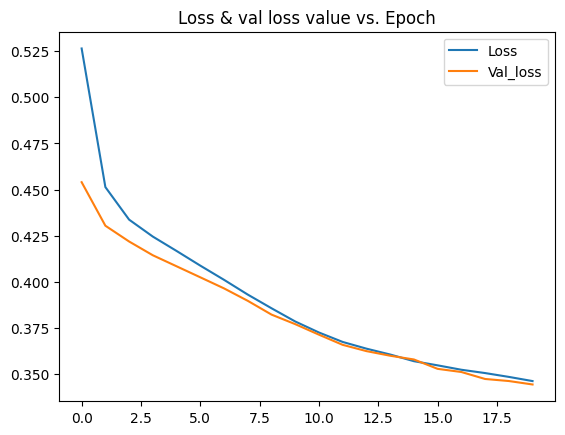

In [119]:
# Check the loss and accuracy history of the model

import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss & val loss value vs. Epoch")
plt.legend(["Loss", "Val_loss"])
plt.show()

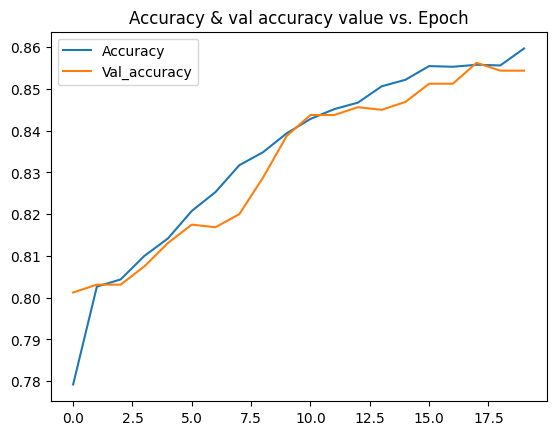

In [120]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy & val accuracy value vs. Epoch")
plt.legend(["Accuracy", "Val_accuracy"])
plt.show()